In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV
from services import slope_and_elevation, population, temperature

In [2]:
# Load and inspect data
df = pd.read_csv('bike_usage_extended.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (90, 14)


,City,Country,Bicycle Usage,Bicycle Roads,Bicycle Rental Stations,Bicycle Stolen,lat,lon,average_slope,elevation,pop,temp_q1,temp_median,temp_q3
0,Utrecht,Netherlands,51.0,60.78,21.77,78.99,52.090701,5.121563,4.250,15.0,18228742.0,6.0610,11.461000,16.611000
1,Munster,Germany,39.1,53.05,35.52,83.04,51.962510,7.625188,7.875,64.0,84552242.0,5.3175,11.117499,16.717501
2,Antwerp,Belgium,28.9,53.37,78.87,84.61,51.221110,4.399708,3.375,12.0,11738763.0,6.5180,11.930500,17.230499
3,Copenhagen,Denmark,29.0,61.60,12.17,66.62,55.686724,12.570072,11.500,13.0,5977412.0,4.6455,10.045500,15.145500
4,Amsterdam,Netherlands,32.0,61.71,32.06,84.49,52.373080,4.892453,5.500,13.0,18228742.0,6.1960,11.296000,16.195999



Missing values:
City                       0
Country                    0
Bicycle Usage              0
Bicycle Roads              0
Bicycle Rental Stations    0
Bicycle Stolen             0
lat                        0
lon                        0
average_slope              0
elevation                  0
pop                        2
temp_q1                    0
temp_median                0
temp_q3                    0
dtype: int64

Descriptive statistics:
       Bicycle Usage  Bicycle Roads  Bicycle Rental Stations  Bicycle Stolen  \
count      90.000000      90.000000                90.000000       90.000000   
mean        8.806667      43.820111                20.722667       83.015111   
std         9.376432      15.006847                20.058466       17.957067   
min         0.030000       1.430000                 1.000000        1.000000   
25%         2.000000      34.442500                 5.645000       82.867500   
50%         6.000000      49.845000                13.96000

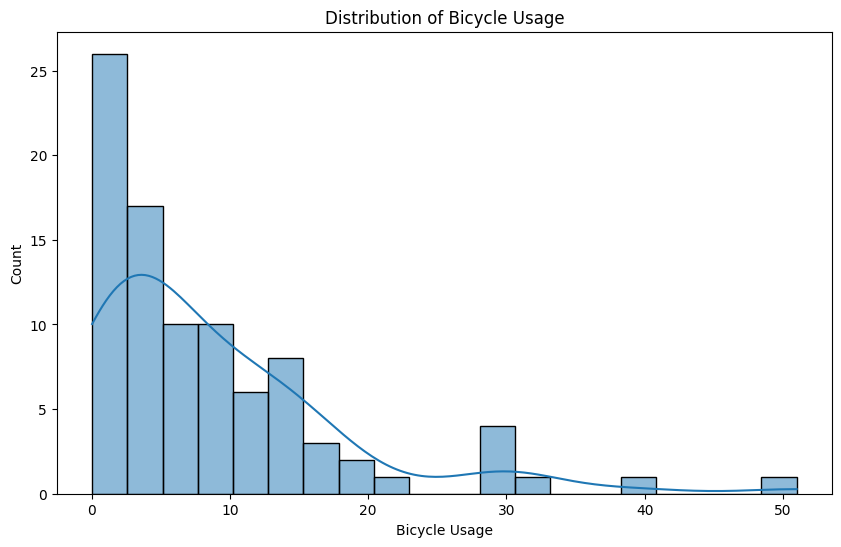

In [3]:
# Basic data exploration
print("\nMissing values:")
print(df.isnull().sum())

print("\nDescriptive statistics:")
print(df.describe())

# Visualize target variable distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Bicycle Usage'], bins=20, kde=True)
plt.title('Distribution of Bicycle Usage')
plt.show()

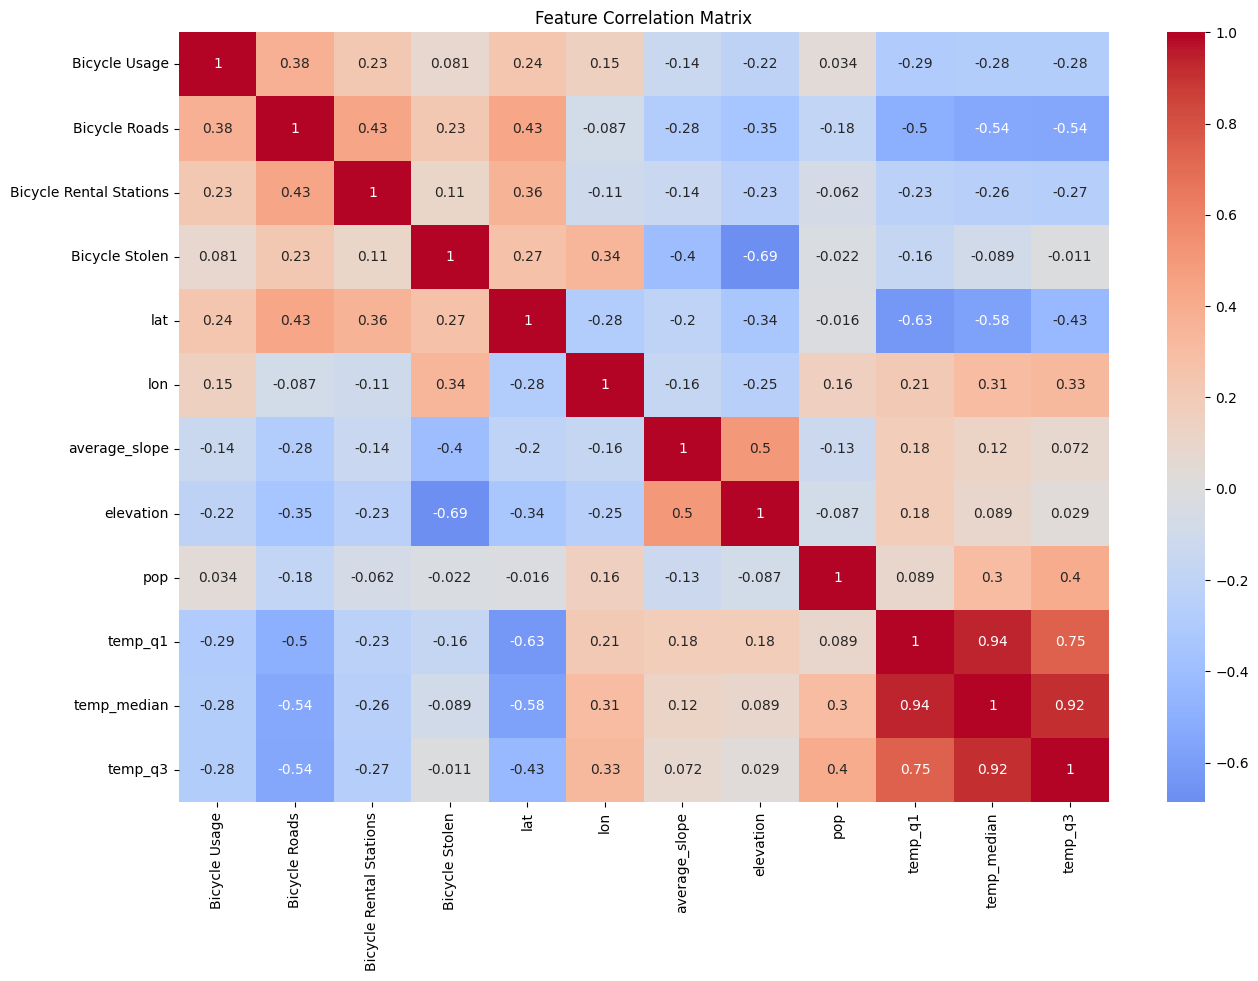

In [4]:
# Correlation analysis
plt.figure(figsize=(15, 10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.show()

In [5]:
# Feature engineering and preprocessing
# Handle missing values (population has some missing values)
df['pop'] = df['pop'].fillna(df['pop'].median())

# Select features and target
X = df.drop(['Bicycle Usage', 'City', 'Country'], axis=1)
y = df['Bicycle Usage']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# Model 1: Linear Regression
print("\n=== Linear Regression ===")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Evaluate
mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MSE: {mse_lr:.2f}")
print(f"MAE: {mae_lr:.2f}")
print(f"R²: {r2_lr:.2f}")

# Feature importance
lr_coef = pd.DataFrame({'Feature': X.columns, 'Importance': lr.coef_})
lr_coef = lr_coef.sort_values('Importance', ascending=False)
print("\nTop features:")
print(lr_coef.head(10))


=== Linear Regression ===
MSE: 123.96
MAE: 6.34
R²: 0.16

Top features:
                   Feature  Importance
9              temp_median    2.622089
4                      lon    2.230881
7                      pop    1.252816
0            Bicycle Roads    1.211326
1  Bicycle Rental Stations    0.973697
3                      lat    0.533787
5            average_slope    0.412382
2           Bicycle Stolen   -0.651057
6                elevation   -0.721111
8                  temp_q1   -2.431989


In [7]:
# Model 2: Random Forest Regressor
print("\n=== Random Forest Regressor ===")
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MSE: {mse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R²: {r2_rf:.2f}")

# Feature importance
rf_feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
rf_feat_imp = rf_feat_imp.sort_values('Importance', ascending=False)
print("\nTop features:")
print(rf_feat_imp.head(10))


=== Random Forest Regressor ===
MSE: 56.38
MAE: 4.54
R²: 0.62

Top features:
                    Feature  Importance
5             average_slope    0.184762
3                       lat    0.124034
1   Bicycle Rental Stations    0.115299
8                   temp_q1    0.099149
4                       lon    0.091802
0             Bicycle Roads    0.089432
2            Bicycle Stolen    0.084253
6                 elevation    0.065430
10                  temp_q3    0.060137
7                       pop    0.049132


In [8]:
# Model 3: Gradient Boosting Regressor
print("\n=== Gradient Boosting Regressor ===")
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

# Evaluate
mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"MSE: {mse_gb:.2f}")
print(f"MAE: {mae_gb:.2f}")
print(f"R²: {r2_gb:.2f}")

# Feature importance
gb_feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': gb.feature_importances_})
gb_feat_imp = gb_feat_imp.sort_values('Importance', ascending=False)
print("\nTop features:")
print(gb_feat_imp.head(10))


=== Gradient Boosting Regressor ===
MSE: 45.30
MAE: 3.93
R²: 0.69

Top features:
                    Feature  Importance
5             average_slope    0.205608
4                       lon    0.148023
8                   temp_q1    0.144754
3                       lat    0.134716
10                  temp_q3    0.121141
0             Bicycle Roads    0.063653
9               temp_median    0.052405
1   Bicycle Rental Stations    0.046144
2            Bicycle Stolen    0.031801
7                       pop    0.026003


In [9]:
# Hyperparameter tuning for the best model (Gradient Boosting in this case)
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_tuned = GridSearchCV(GradientBoostingRegressor(random_state=42), 
                       param_grid, 
                       cv=5, 
                       scoring='neg_mean_squared_error',
                       n_jobs=-1)
gb_tuned.fit(X_train, y_train)

print("\nBest parameters:", gb_tuned.best_params_)


Best parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 50}


In [10]:
# Evaluate tuned model
y_pred_gb_tuned = gb_tuned.predict(X_test)
mse_gb_tuned = mean_squared_error(y_test, y_pred_gb_tuned)
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)

print("\n=== Tuned Gradient Boosting ===")
print(f"MSE: {mse_gb_tuned:.2f}")
print(f"MAE: {mae_gb_tuned:.2f}")
print(f"R²: {r2_gb_tuned:.2f}")


=== Tuned Gradient Boosting ===
MSE: 104.45
MAE: 6.30
R²: 0.29


In [11]:
# Compare model performance
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Tuned Gradient Boosting'],
    'MSE': [mse_lr, mse_rf, mse_gb, mse_gb_tuned],
    'MAE': [mae_lr, mae_rf, mae_gb, mae_gb_tuned],
    'R²': [r2_lr, r2_rf, r2_gb, r2_gb_tuned]
})

print("\nModel Comparison:")
print(results.sort_values('R²', ascending=False))


Model Comparison:
                     Model         MSE       MAE        R²
2        Gradient Boosting   45.301002  3.928394  0.694054
1            Random Forest   56.380385  4.544744  0.619228
3  Tuned Gradient Boosting  104.450571  6.298025  0.294580
0        Linear Regression  123.961918  6.336742  0.162808


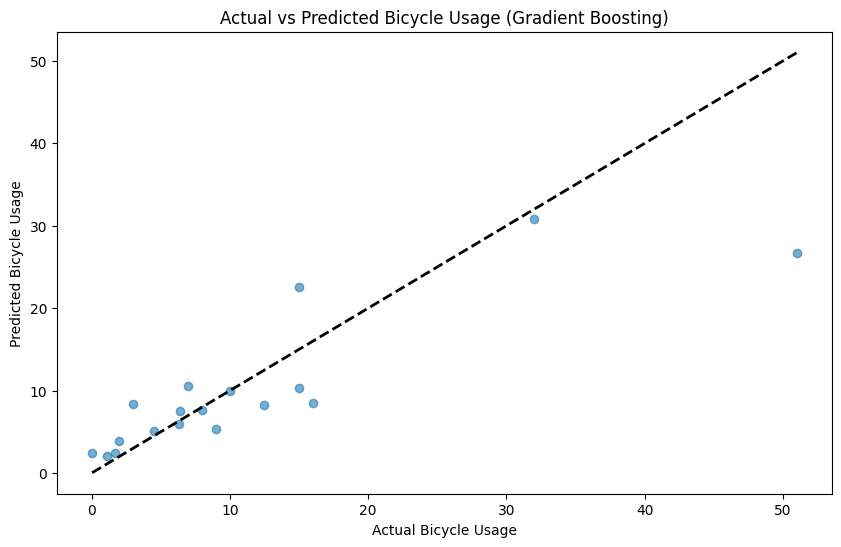

In [12]:
# Visualize actual vs predicted values for the best model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_gb, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Bicycle Usage')
plt.ylabel('Predicted Bicycle Usage')
plt.title('Actual vs Predicted Bicycle Usage (Gradient Boosting)')
plt.show()

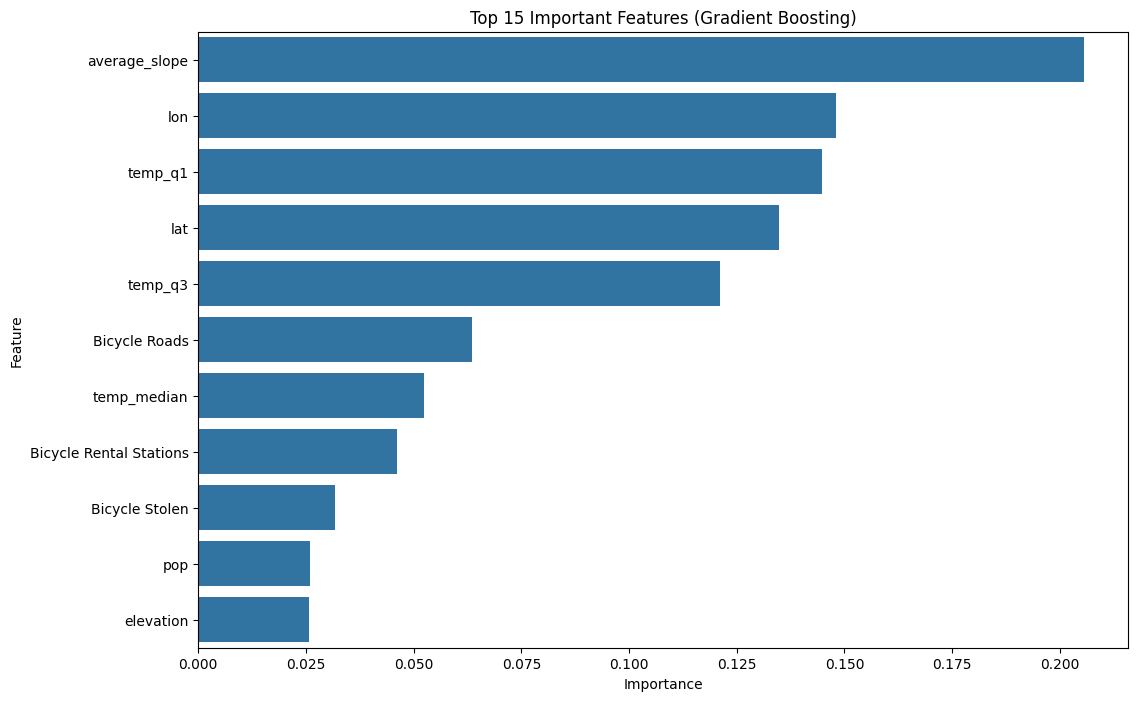

In [13]:
# Feature importance visualization for the best model
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=gb_feat_imp.head(15))
plt.title('Top 15 Important Features (Gradient Boosting)')
plt.show()

In [18]:
# Interactive prediction widget
import ipywidgets as widgets
from IPython.display import display

def predict_bicycle_usage(city, country):
    """
    Predict bicycle usage for a given city and country using the trained Gradient Boosting model
    """
    try:
        # Fetch data for the new city
        print(f"Fetching data for {city}, {country}...")
        lat, lon, average_slope, elevation = slope_and_elevation(city, country)
        pop = population(country)
        temp_q1, temp_median, temp_q3 = temperature(lat, lon)
        
        # Check if any data is missing
        if any(x is None or (isinstance(x, float) and np.isnan(x)) for x in [lat, lon, average_slope, elevation, pop, temp_q1, temp_median, temp_q3]):
            print("❌ Could not fetch complete data for this city. Please try another city.")
            return
        
        # Calculate median values for missing features from the training dataset
        bicycle_rental_stations_median = df['Bicycle Rental Stations'].median()
        bicycle_roads_median = df['Bicycle Roads'].median()
        bicycle_stolen_median = df['Bicycle Stolen'].median()
        
        # Create input dataframe with the same structure as training data
        input_data = {
            'Bicycle Rental Stations': [bicycle_rental_stations_median],
            'Bicycle Roads': [bicycle_roads_median], 
            'Bicycle Stolen': [bicycle_stolen_median],
            'lat': [lat],
            'lon': [lon], 
            'average_slope': [average_slope],
            'elevation': [elevation],
            'pop': [pop],
            'temp_q1': [temp_q1],
            'temp_median': [temp_median],
            'temp_q3': [temp_q3]
        }
        
        input_df = pd.DataFrame(input_data)
        
        # Ensure the column order matches the training data
        input_df = input_df[X.columns]
        
        # Make prediction using the trained Gradient Boosting model
        predicted_usage = gb.predict(input_df)[0]
        
        # Display results
        print(f"🚴 BICYCLE USAGE PREDICTION 🚴")
        print(f"{'='*50}")
        print(f"City: {city}, {country}")
        print(f"Coordinates: {lat:.2f}°, {lon:.2f}°")
        print(f"Elevation: {elevation:.0f}m")
        print(f"Average Slope: {average_slope:.2f}m")
        print(f"Population: {pop/1_000_000:.1f} million")
        print(f"Temperature (Q1/Median/Q3): {temp_q1:.1f}°C / {temp_median:.1f}°C / {temp_q3:.1f}°C")
        print(f"⚠️  Missing data filled with medians:")
        print(f"   Rental Stations: {bicycle_rental_stations_median:.0f}")
        print(f"   Bicycle Roads: {bicycle_roads_median:.0f}")
        print(f"   Bicycle Stolen: {bicycle_stolen_median:.0f}")
        print(f"{'='*50}")
        print(f"🎯 PREDICTED BICYCLE USAGE: {predicted_usage:.1f}%")
        print(f"{'='*50}")
        
        # Compare with cities in dataset
        similar_usage = df[np.abs(df['Bicycle Usage'] - predicted_usage) < 5]['City'].tolist()[:3]
        if similar_usage:
            print(f"💡 Cities with similar usage: {', '.join(similar_usage)}")
        
    except Exception as e:
        print(f"❌ Error occurred: {str(e)}")
        print("Please check the city name and country, and try again.")

# Create interactive widgets
city_widget = widgets.Text(
    value='Budapest',
    placeholder='Enter city name',
    description='City:',
    style={'description_width': 'initial'}
)

country_widget = widgets.Text(
    value='Hungary',
    placeholder='Enter country name', 
    description='Country:',
    style={'description_width': 'initial'}
)

predict_button = widgets.Button(
    description='🔮 Predict Bicycle Usage',
    button_style='success',
    layout=widgets.Layout(width='200px', height='40px')
)

output = widgets.Output()

def on_predict_click(b):
    with output:
        output.clear_output()
        predict_bicycle_usage(city_widget.value, country_widget.value)

predict_button.on_click(on_predict_click)

# Display widgets
print("🚴 BICYCLE USAGE PREDICTOR 🚴")
print("Enter a city and country to predict bicycle usage percentage:")
display(widgets.VBox([
    widgets.HBox([city_widget, country_widget]),
    predict_button,
    output
]))

🚴 BICYCLE USAGE PREDICTOR 🚴
Enter a city and country to predict bicycle usage percentage:
